In [55]:
import pandas as pd
import numpy as np
import seaborn as sns


In [56]:
df = pd.read_csv('spam.csv', encoding='iso8859-15')

In [57]:
import chardet

with open('spam.csv', 'rb') as f:
    result = chardet.detect(f.read())

print(result)

{'encoding': 'iso8859-15', 'confidence': 0.27600091856510656, 'language': 'en', 'mime_type': 'text/plain'}


In [58]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [59]:
# 1. Data cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

# 1- Data Cleaning

In [60]:
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

In [61]:
df.rename(columns={'v1':'target','v2':'message'},inplace=True)

In [62]:
df.head()

,target,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [63]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target']=encoder.fit_transform(df['target'])

In [64]:
df.head()

,target,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [65]:
df.shape

(5572, 2)

In [66]:
df.isnull().sum()

target     0
message    0
dtype: int64

In [67]:
df.duplicated().sum()

np.int64(403)

In [68]:
df = df.drop_duplicates(keep='first')

In [69]:
df.shape

(5169, 2)

# EDA

In [70]:
df.info()

<class 'pandas.DataFrame'>
Index: 5169 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   target   5169 non-null   int64
 1   message  5169 non-null   str  
dtypes: int64(1), str(1)
memory usage: 121.1 KB


In [71]:
df['target'].describe()

count    5169.000000
mean        0.126330
std         0.332253
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: target, dtype: float64

In [72]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

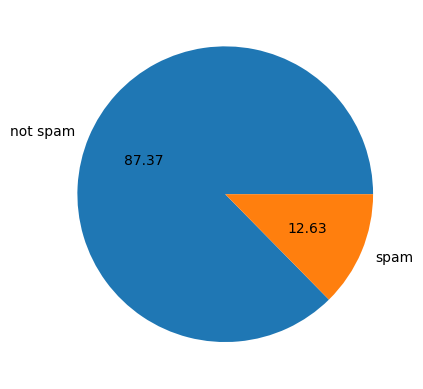

In [73]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=('not spam','spam'), autopct='%0.2f')
plt.show()

In [74]:
import nltk

In [75]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to C:\Users\Waqas
[nltk_data]     Kareem\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [76]:
df['num_char'] = df['message'].apply(len)

In [77]:
df.head()

,target,message,num_char
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [78]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to C:\Users\Waqas
[nltk_data]     Kareem\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [79]:
df['num_words'] = df['message'].apply(lambda x:len(nltk.word_tokenize(x)))

In [80]:
df['num_sent'] = df['message'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [81]:
df.head()

,target,message,num_char,num_words,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [82]:
df[['num_char','num_words','num_sent']].describe()

,num_char,num_words,num_sent
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [83]:
df[df['target']==0][['num_char','num_words','num_sent']].describe()

,num_char,num_words,num_sent
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [84]:
df[df['target']==1][['num_char','num_words','num_sent']].describe()

,num_char,num_words,num_sent
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [85]:
import seaborn as sns

<Axes: xlabel='num_char', ylabel='Count'>

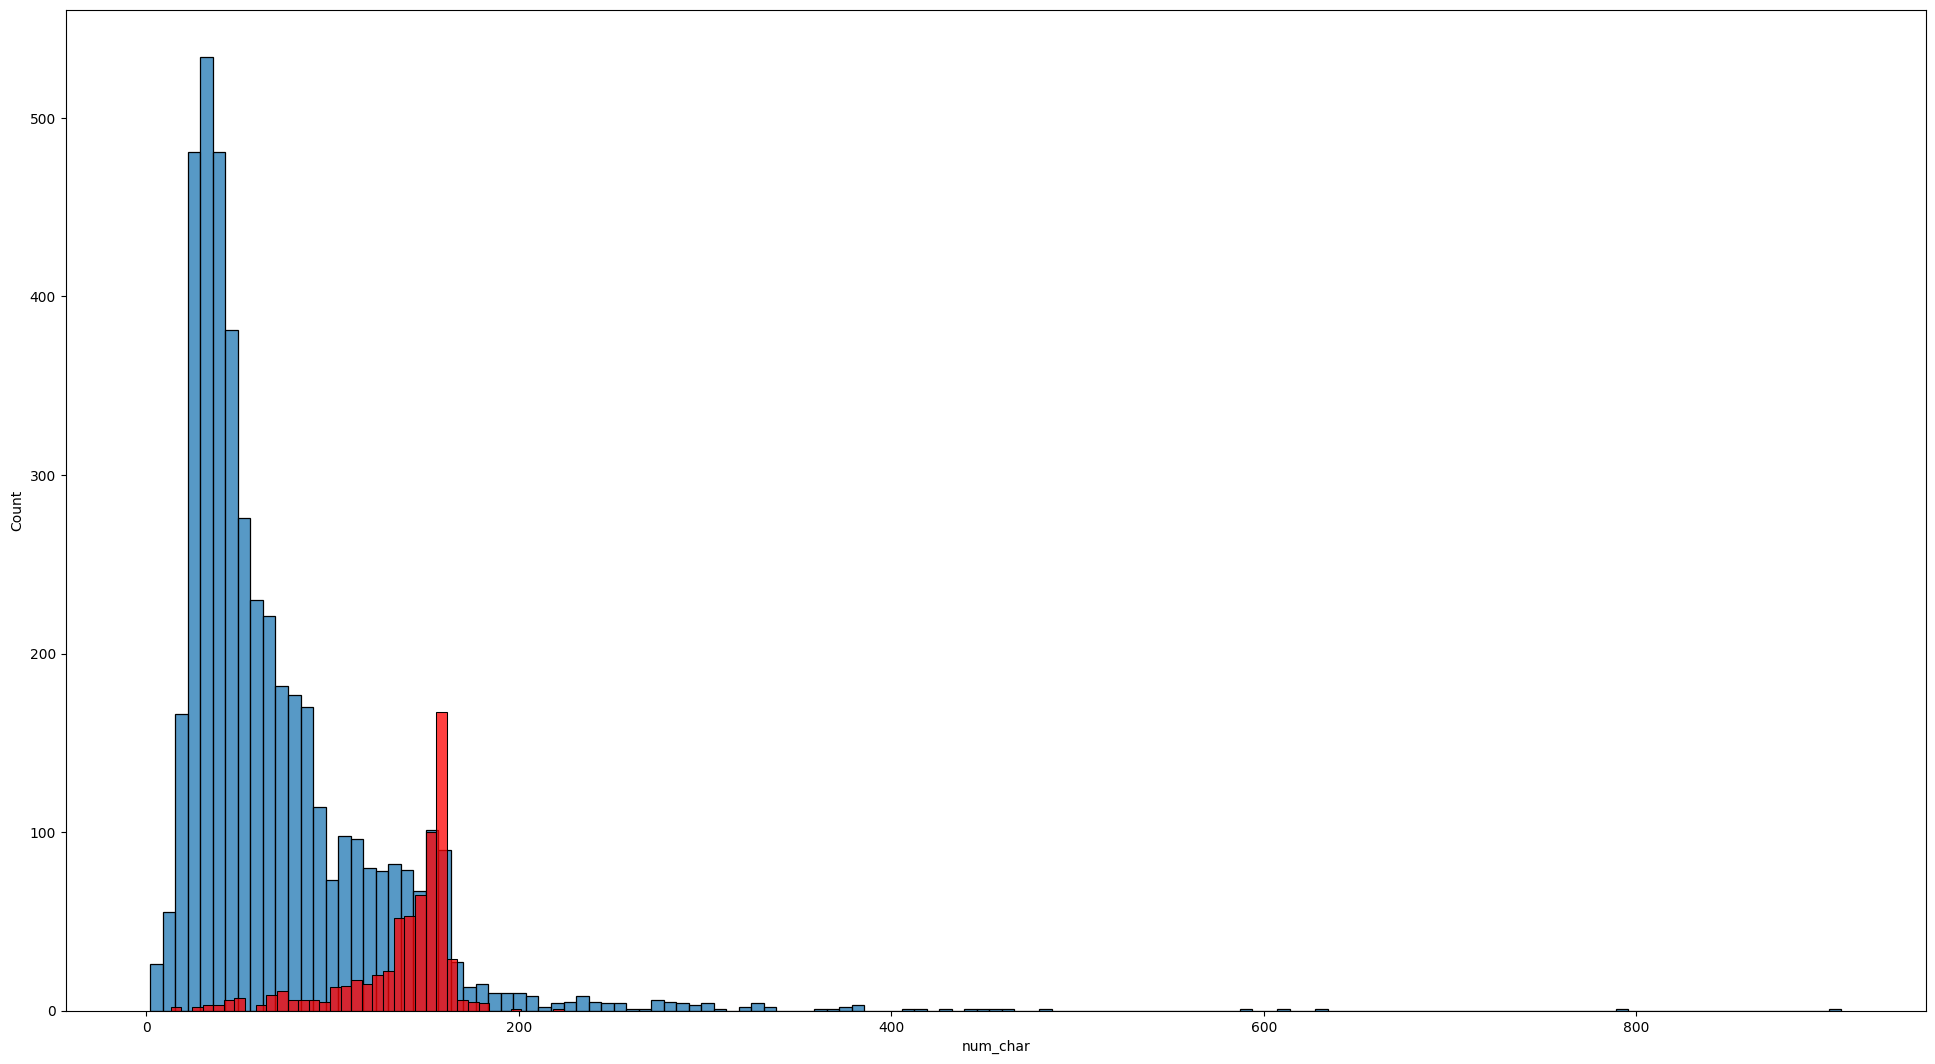

In [86]:
plt.figure(figsize=(24,13))
sns.histplot(df[df['target']==0]['num_char'])
sns.histplot(df[df['target']==1]['num_char'],color='red')

<Axes: xlabel='num_words', ylabel='Count'>

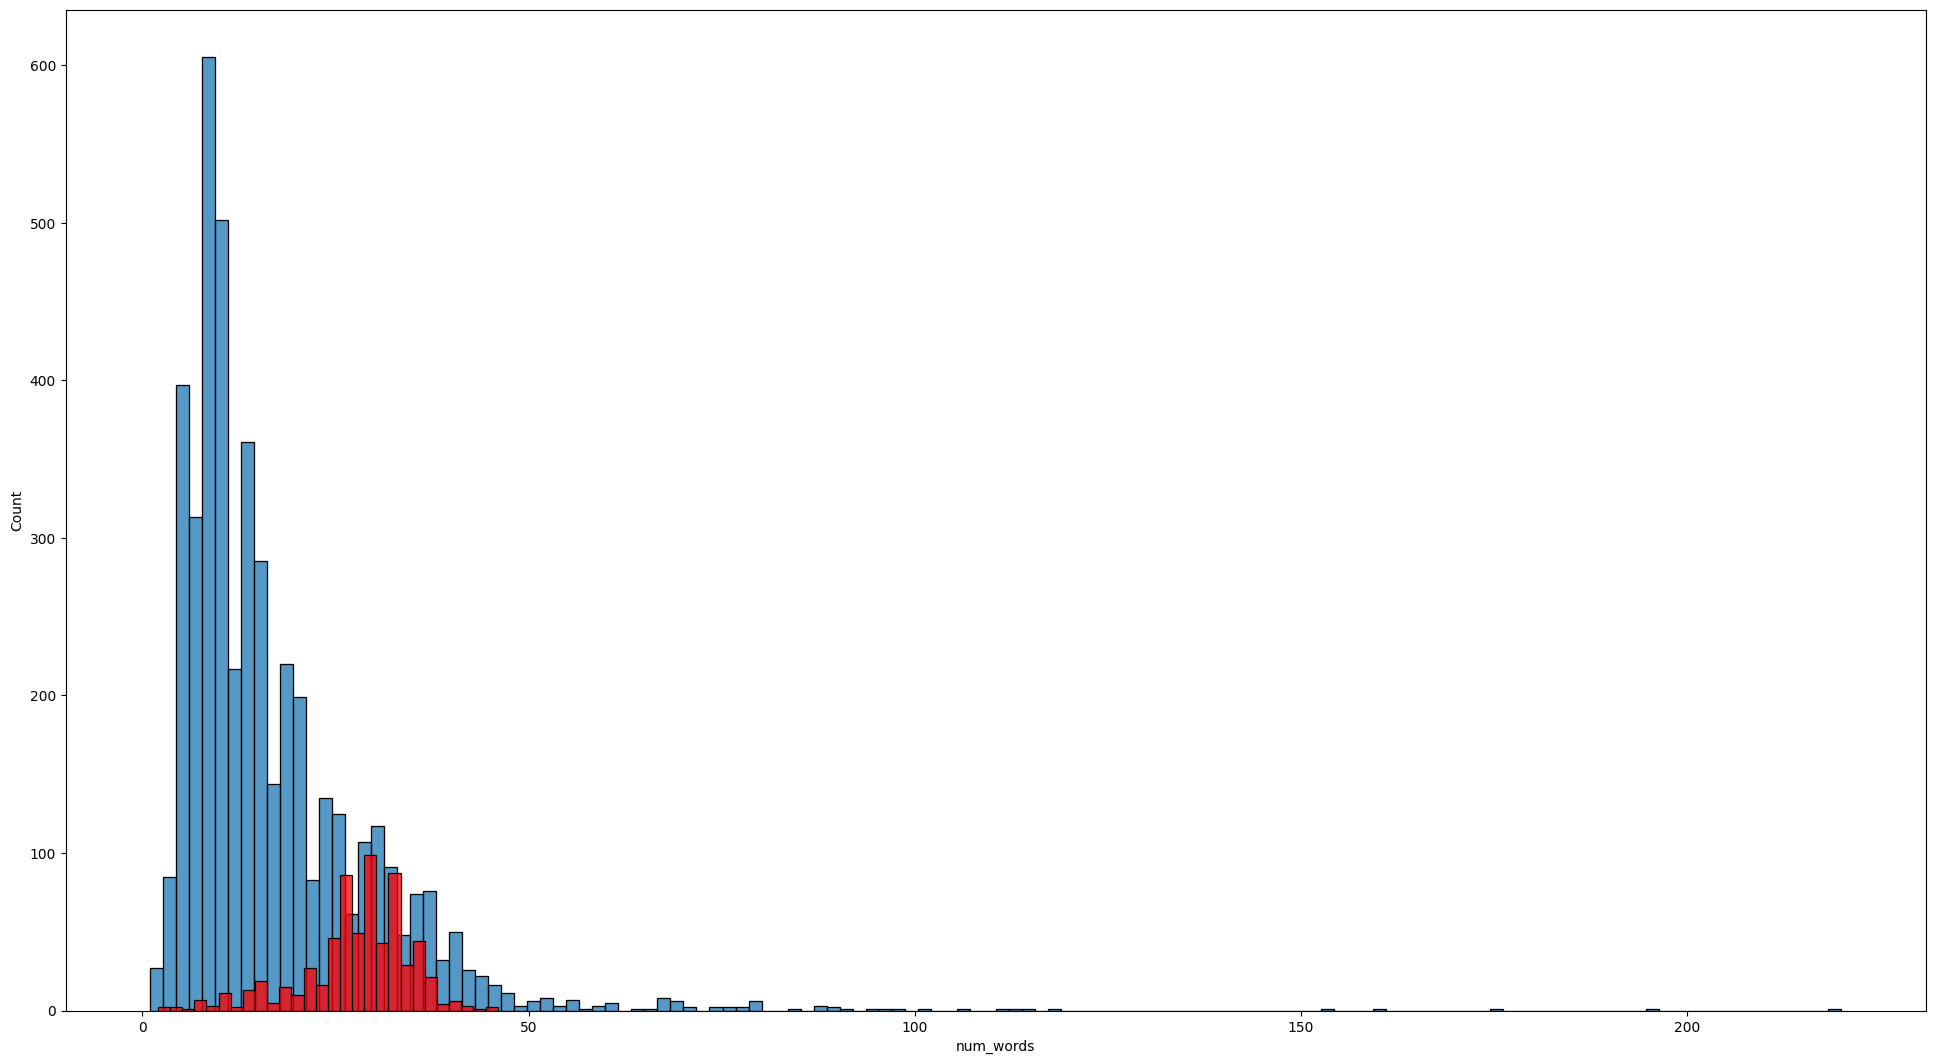

In [87]:
plt.figure(figsize=(24,13))
sns.histplot(df[df['target']==0]['num_words'])
sns.histplot(df[df['target']==1]['num_words'],color='red')

<Axes: xlabel='num_sent', ylabel='Count'>

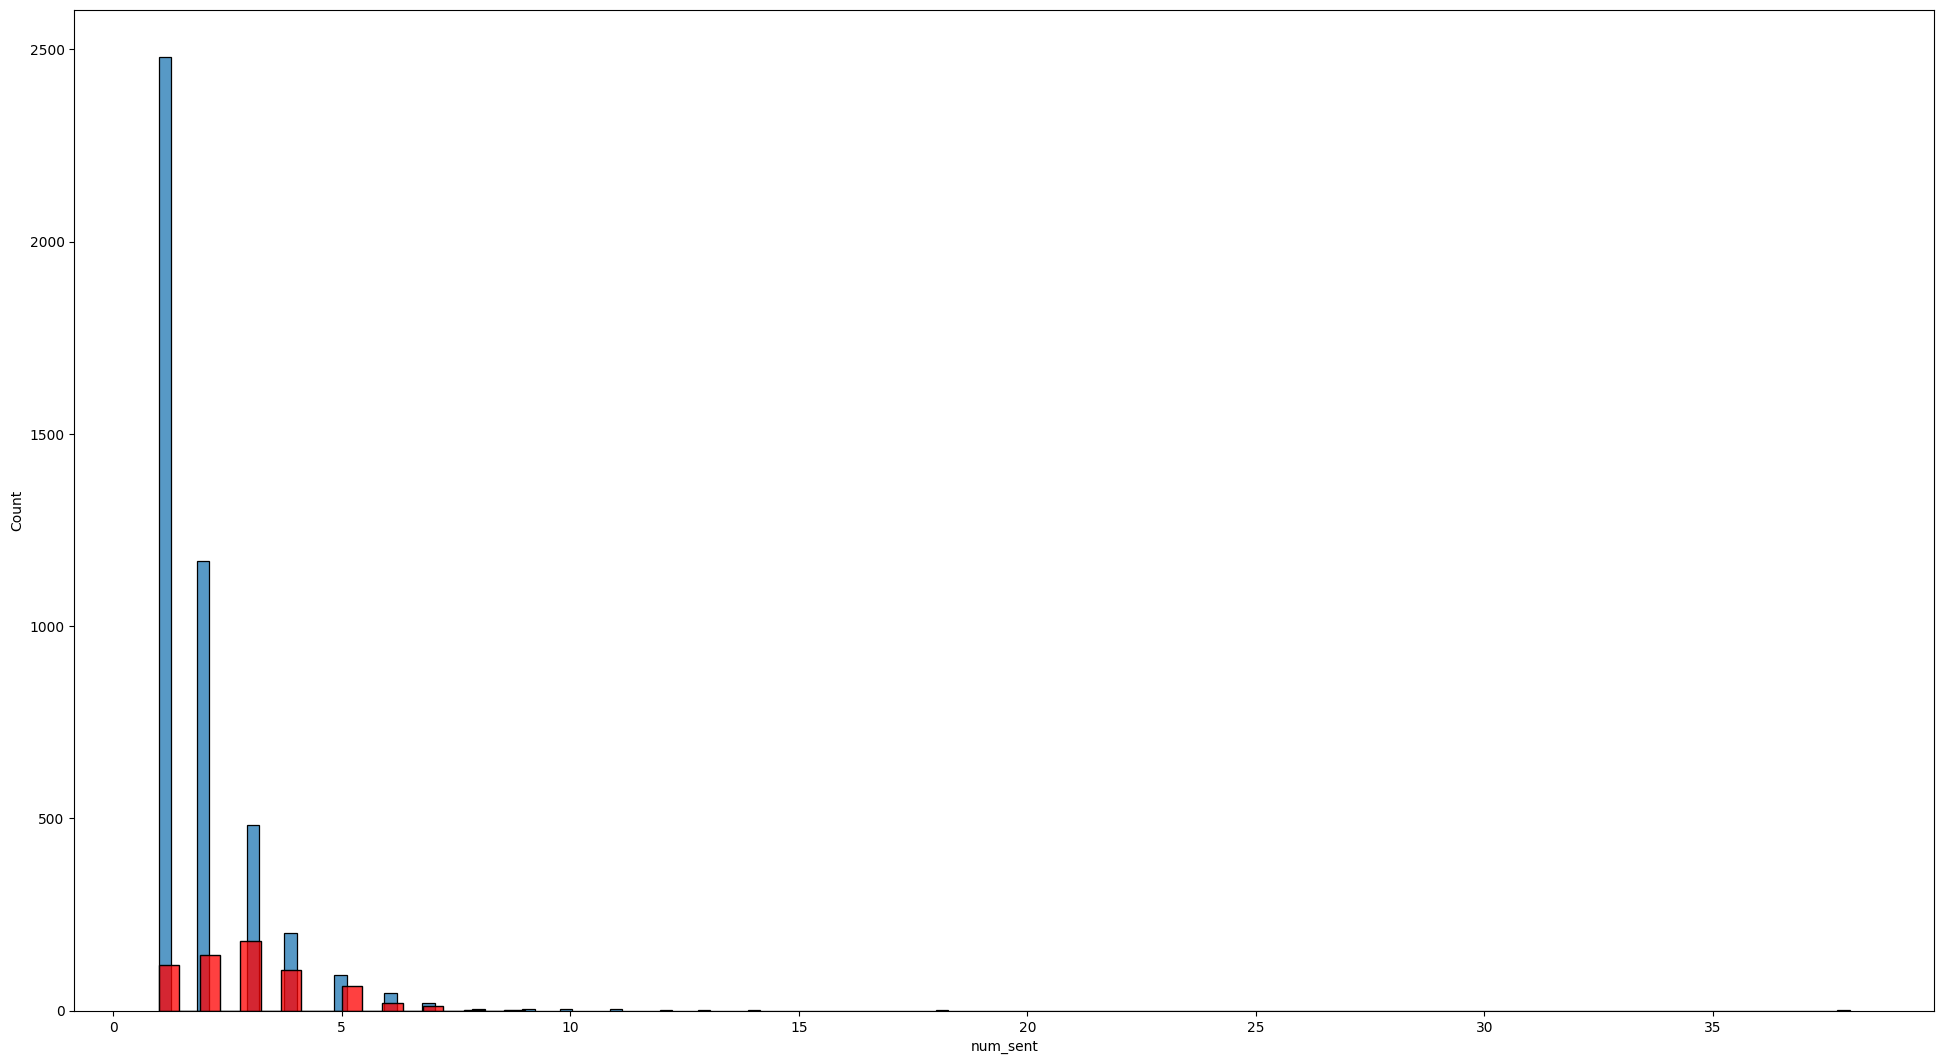

In [88]:
plt.figure(figsize=(24,13))
sns.histplot(df[df['target']==0]['num_sent'])
sns.histplot(df[df['target']==1]['num_sent'],color='red')

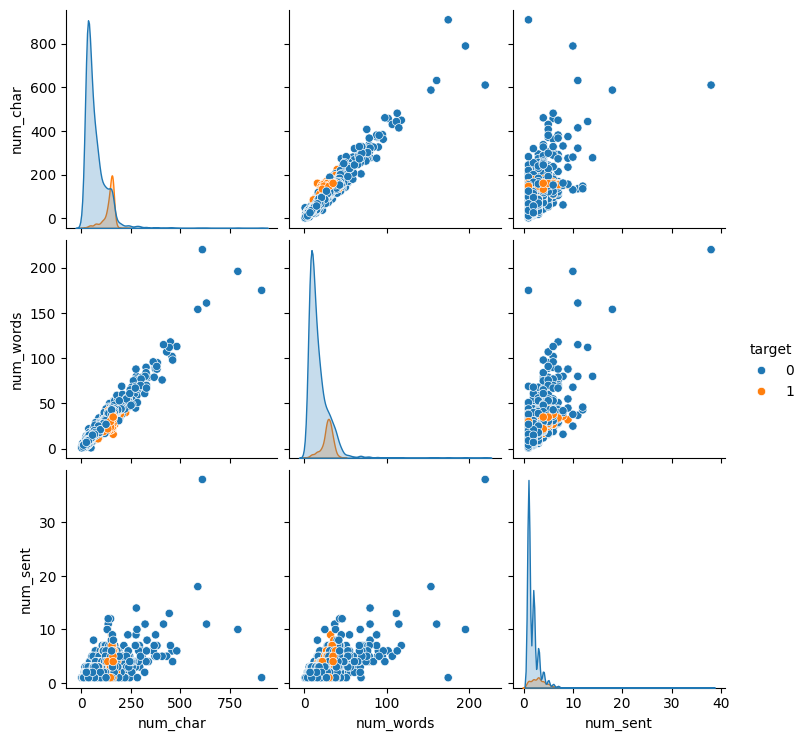

In [89]:
sns.pairplot(df, hue='target')

<Axes: >

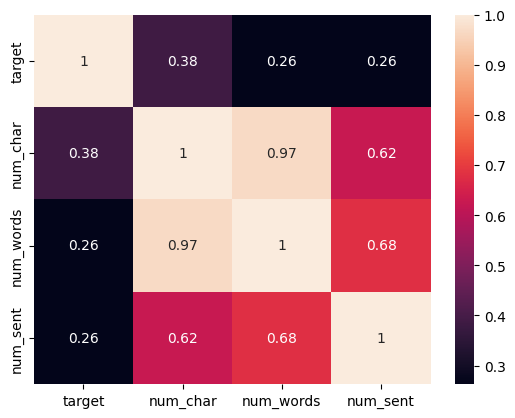

In [90]:
sns.heatmap(df[['target','num_char', 'num_words', 'num_sent']].corr(), annot=True)

# Text Preprocessing
* Lower case
* Tokenization
* Removing special characters
* Removing stop words and punctuation
* Stemming

In [91]:
df.head()

,target,message,num_char,num_words,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [92]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Waqas
[nltk_data]     Kareem\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [93]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [94]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [99]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [100]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)
    
    y=[]
    for i in text:
        if i.isalnum:
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    
    text = y[:]
    y.clear()
    
    for i in text:
        y.append(ps.stem(i))
            
    return " ".join(y) 

In [101]:
transform_text('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...')

'go jurong point crazi .. avail bugi n great world la e buffet ... cine got amor wat ...'

In [ ]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()


In [102]:
df['transformed_text'] = df['message'].apply(lambda x:transform_text(x))

In [103]:
df.head()

,target,message,num_char,num_words,num_sent,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi .. avail bugi n great wo...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar ... joke wif u oni ...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor ... u c alreadi say ...
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah n't think goe usf live around though


In [104]:
from wordcloud import WordCloud

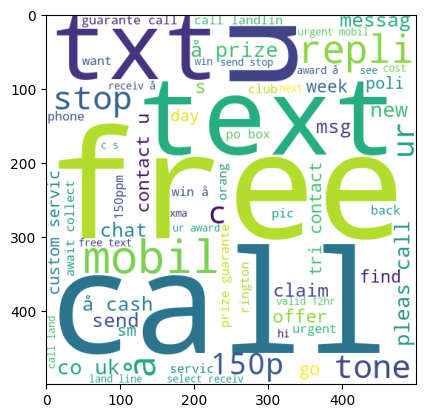

In [105]:
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')
spam_wc=wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))
plt.imshow(wc)


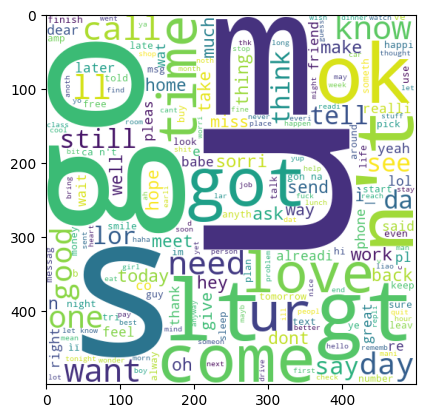

In [ ]:
ham_wc=wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))
plt.imshow(wc)

In [ ]:
df.head()

,target,message,num_char,num_words,num_sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [107]:
spam_messages = df[df['target']==1]['transformed_text'].tolist()

In [108]:
spam_messages

["free entri 2 wkli comp win fa cup final tkt 21st may 2005. text fa 87121 receiv entri question std txt rate c 's appli 08452810075over18 's",
 "freemsg hey darl 's 3 week 's word back 'd like fun still tb ok xxx std chg send å£1.50 rcv",
 'winner valu network custom select receivea å£900 prize reward claim call 09061701461. claim code kl341 valid 12 hour',
 'mobil 11 month u r entitl updat latest colour mobil camera free call mobil updat co free 08002986030',
 'six chanc win cash 100 20,000 pound txt csh11 send 87575. cost 150p/day 6day 16+ tsandc appli repli hl 4 info',
 'urgent 1 week free membership å£100,000 prize jackpot txt word claim 81010 c www.dbuk.net lccltd pobox 4403ldnw1a7rw18',
 'xxxmobilemovieclub use credit click wap link next txt messag click http //wap xxxmobilemovieclub.com n=qjkgighjjgcbl',
 'england v macedonia dont miss goals/team news txt ur nation team 87077 eg england 87077 tri wale scotland 4txt/ìœ1.20 poboxox36504w45wq 16+',
 'thank subscript rington uk mob

In [109]:
words = []
for msg in spam_messages:
    words.extend(nltk.word_tokenize(msg))

In [110]:
from collections import Counter
pd.DataFrame(Counter(words).most_common(30))

,0,1
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
5,u,119
6,ur,119
7,mobil,114
8,stop,104
9,repli,103


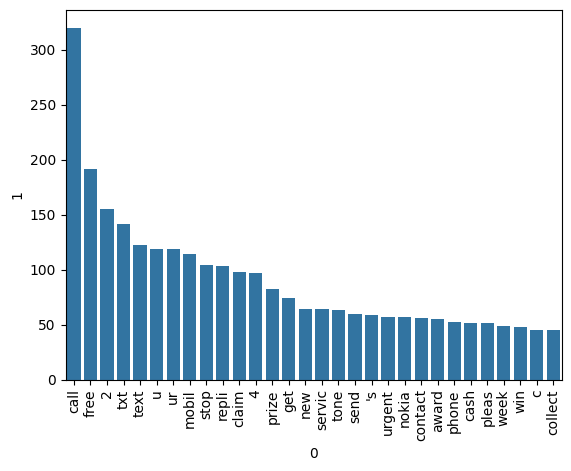

In [111]:
sns.barplot(x=pd.DataFrame(Counter(words).most_common(30))[0], y=pd.DataFrame(Counter(words).most_common(30))[1])
plt.xticks(rotation = 'vertical')
plt.show()

# Model Buliding

In [112]:
df.head()

,target,message,num_char,num_words,num_sent,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi .. avail bugi n great wo...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar ... joke wif u oni ...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor ... u c alreadi say ...
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah n't think goe usf live around though


In [165]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2))

In [166]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [167]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(5169, 3000))

In [168]:
y = df['target'].values

In [169]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [170]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
gnb = GaussianNB()
bnb = BernoulliNB()
mbn = MultinomialNB()

In [119]:
gnb.fit(X_train, y_train)
pred1 = gnb.predict(X_test)

In [120]:
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

In [171]:
print(accuracy_score(y_test, pred1))
print(precision_score(y_test, pred1))
print(confusion_matrix(y_test, pred1))

0.8800773694390716
0.5307017543859649
[[789 107]
 [ 17 121]]


In [175]:
bnb.fit(X_train, y_train)
pred2 = bnb.predict(X_test)
print(accuracy_score(y_test, pred2))
print(confusion_matrix(y_test, pred2))
print(precision_score(y_test, pred2))
print(recall_score(y_test, pred2))

0.9854932301740812
[[896   0]
 [ 15 123]]
1.0
0.8913043478260869


In [174]:
mbn.fit(X_train, y_train)
pred3 = mbn.predict(X_test)
print(accuracy_score(y_test, pred3))
print(confusion_matrix(y_test, pred3))
print(precision_score(y_test, pred3))
print(recall_score(y_test, pred3))

0.97678916827853
[[896   0]
 [ 24 114]]
1.0
0.8260869565217391


TFIDF -> BNB

In [124]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier



In [125]:
lr = LogisticRegression(solver='liblinear', max_iter=3, random_state=2)
svc = SVC(kernel='sigmoid',gamma=1.0)
knn = KNeighborsClassifier()
bnb = BernoulliNB()
bgc = BaggingClassifier(n_estimators=50, random_state=2)
gbc = GradientBoostingClassifier(n_estimators=50, random_state=2)
xgbc = XGBClassifier(n_estimators = 50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
dtc = DecisionTreeClassifier(max_depth=5)
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50 , random_state=2)


In [ ]:
lr = LogisticRegression(solver='liblinear', penalty='l1', max_iter=3, random_state=2)
lr.fit(X_train, y_train)
pred = lr.predict(X_test)
print(precision_score(y_test, pred))
print(accuracy_score(y_test, pred))


0.9622641509433962
0.9613152804642167


d:\Spam Classifier\svenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\Spam Classifier\svenv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
d:\Spam Classifier\svenv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [176]:
clfs = {
    'lr': lr,
    'svc': svc,
    'knn': knn,
    'bnb': bnb,
    'mnb':mbn,
    'bgc': bgc,
    'gbc': gbc,
    'xgbc': xgbc,
    'abc': abc,
    'dtc': dtc,
    'rfc':rfc,
    'etc':etc
}

In [158]:
from sklearn.metrics import recall_score

In [177]:
def train_classifier(clf, X_train, X_test, y_train, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy= accuracy_score(y_test, y_pred)
    precison= precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    return accuracy, precison, recall

In [178]:
train_classifier(lr, X_train, X_test, y_train, y_test)

d:\Spam Classifier\svenv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\Spam Classifier\svenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


(0.8665377176015474, 0.0, 0.0)

In [179]:
accuracy_scores = []
precision_scores = []
recall_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision, current_recall = train_classifier(clf, X_train, X_test, y_train, y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    print("Recall", current_recall)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    recall_scores.append(current_recall)

d:\Spam Classifier\svenv\Lib\site-packages\sklearn\svm\_base.py:1258: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
d:\Spam Classifier\svenv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


For  lr
Accuracy -  0.8665377176015474
Precision -  0.0
Recall 0.0
For  svc
Accuracy -  0.9787234042553191
Precision -  0.9754098360655737
Recall 0.8623188405797102
For  knn
Accuracy -  0.9081237911025145
Precision -  1.0
Recall 0.3115942028985507
For  bnb
Accuracy -  0.9854932301740812
Precision -  1.0
Recall 0.8913043478260869
For  mnb
Accuracy -  0.97678916827853
Precision -  1.0
Recall 0.8260869565217391
For  bgc
Accuracy -  0.9584139264990329
Precision -  0.8682170542635659
Recall 0.8115942028985508
For  gbc
Accuracy -  0.9526112185686654
Precision -  0.9587628865979382
Recall 0.6739130434782609
For  xgbc
Accuracy -  0.9700193423597679
Precision -  0.9572649572649573
Recall 0.8115942028985508
For  abc
Accuracy -  0.9235976789168279
Precision -  0.927536231884058
Recall 0.463768115942029
For  dtc
Accuracy -  0.9323017408123792
Precision -  0.8777777777777778
Recall 0.572463768115942
For  rfc
Accuracy -  0.97678916827853
Precision -  0.9830508474576272
Recall 0.8405797101449275
For 

In [163]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores,'Recall':recall_scores}).sort_values('Precision',ascending=False)

In [164]:
performance_df

,Algorithm,Accuracy,Precision,Recall
2,knn,0.905222,1.000000,0.289855
9,rfc,0.979691,1.000000,0.847826
3,bnb,0.988395,1.000000,0.913043
10,etc,0.978723,0.983333,0.855072
1,svc,0.974855,0.974576,0.833333
5,gbc,0.947776,0.956522,0.637681
6,xgbc,0.973888,0.951220,0.847826
7,abc,0.920696,0.868421,0.478261
8,dtc,0.934236,0.864583,0.601449
4,bgc,0.957447,0.845588,0.833333


In [132]:
from sklearn.ensemble import VotingClassifier

In [140]:
estimators = [
    ('knn',knn),
    ('rfc', rfc),
    ('bnb',bnb)
]

In [141]:
voting = VotingClassifier(estimators=estimators )

In [142]:
voting.fit(X_train, y_train)
y_pred_v = voting.predict(X_test)


In [143]:
print(accuracy_score(y_test, y_pred_v))
print(precision_score(y_test, y_pred_v))

0.9787234042553191
1.0


In [144]:
import pickle

In [151]:
pickle.dump(transform_text(text),open('transform_textt.pkl','wb'))

NameError: name 'text' is not defined

In [155]:
pickle.dump(tfidf, open('vectorizer.pkl','wb'))

In [156]:
pickle.dump(bnb, open('model.pkl', 'wb'))

In [157]:
from sklearn.metrics import recall_score
recall_score(y_test, pred2)

0.9130434782608695

In [180]:
import cloudpickle

# save
with open('transform_text.pkl', 'wb') as f:
    cloudpickle.dump(transform_text, f)